# BUSI 乳腺超声图像分类（良性 vs 恶性）

**任务**：训练一个深度学习模型，根据乳腺超声图像（BUS image）预测肿瘤是 **良性（benign）** 还是 **恶性（malignant）**。

**模型**：ResNet50，加载在 ImageNet 上预训练的权重，替换最后的全连接层做二分类。

**数据**：BUSI 数据集，输入图像统一 resize 到 224×224；数据集自带两个 `.xlsx` 文件，分别给出训练集和测试集的划分。

**这个 notebook 的结构**：
1. 配置（路径、超参数）
2. 导入库
3. 读取并检查数据划分文件（.xlsx）
4. 构建 Dataset / DataLoader（含预处理和数据增强）
5. 可视化几个样本，确认数据加载正确
6. 构建 ResNet50 模型
7. 定义损失函数与优化器
8. 训练循环（记录每个 epoch 的 train loss / test loss）
9. 绘制 loss 曲线
10. 在测试集上计算 accuracy / recall / F1 等指标
11. 可视化测试集预测结果（图片 + 真实标签 + 预测标签）
12. 保存模型

> ⚠️ **在运行之前**：请先把 BUSI 数据集上传到服务器的 `~/datasets/BUSI/` 目录下（图片文件夹 + 两个 .xlsx 划分文件），然后检查第 3 节的输出，确认 CONFIG 里的列名/路径设置和实际文件一致，必要时按提示修改。


## 1. 配置（CONFIG）

把所有“会因为环境/数据不同而需要修改”的东西集中放在这里，后面的代码都引用这些变量，方便统一调整。

🔧 **需要你核对/修改的地方**：
- `DATASET_DIR`：数据集所在目录
- `TRAIN_XLSX` / `TEST_XLSX`：训练集/测试集划分文件的文件名（改成你上传的实际文件名）
- `IMAGES_ROOT`：图片所在的根目录（如果 xlsx 里的路径不是相对这个目录，请调整）
- 第 3 节运行后会打印出 xlsx 的列名，如果和代码里自动识别的不一致，请回到这里手动设置 `IMAGE_COL` / `LABEL_COL`


In [1]:
import os

# ===== 路径配置 =====
DATASET_DIR = os.path.expanduser("~/datasets/BUSI")
TRAIN_XLSX = os.path.join(DATASET_DIR, "train.xlsx")
TEST_XLSX = os.path.join(DATASET_DIR, "test.xlsx")
IMAGES_ROOT = os.path.join(DATASET_DIR, "images")

IMAGE_COL = None
LABEL_COL = None

LABEL_MAP = {"benign": 0, "malignant": 1}
CLASS_NAMES = ["benign", "malignant"]

# ===== 训练超参数 =====
IMG_SIZE = 224
BATCH_SIZE = 16  # run14：改回和 run11 一致的 16，只比对 class weight + fbeta 这个变量
NUM_EPOCHS = 20
LEARNING_RATE = 1e-4
NUM_WORKERS = 0
RANDOM_SEED = 42

# ===== train/val 切分：消除"偷看测试集"问题 =====
# 第 3 次里 early stopping 直接拿 test_f1 判断"是不是变好了"，等于训练阶段已经在用测试集调参，
# 汇报出来的 test 指标会偏乐观。这一版把 train.xlsx 的 517 条按 Label 比例分层切成
# train_sub / val（默认 80/20），early stopping 和"保存最佳权重"只看 val_f1；
# test.xlsx 的 130 条全程不参与训练/调参，只在最后跑一次做最终汇报。
VAL_SPLIT_RATIO = 0.2

# run19：对 malignant 类别做过采样（在 run14 的 class weight + F-beta(2) checkpoint 基础上叠加）。
# 选的是"过采样"这个更简单、更容易验证的做法（不是自定义更强的增强变换）：
# 打开后把 train_sub 里的 malignant 行复制一份，让模型每个 epoch 多看一遍这些样本。
MALIGNANT_EXTRA_AUG = True

# ===== 抗过拟合相关超参数（都集中放在这里，改数值重新跑不用翻代码）=====
WEIGHT_DECAY = 1e-2          # AdamW 权重衰减（L2 正则），越大惩罚越强
DROPOUT_P = 0.3              # 分类头前的 dropout 概率
LABEL_SMOOTHING = 0.1        # CrossEntropyLoss 的 label smoothing，让模型别对训练标签太自信
EARLY_STOPPING_PATIENCE = 8  # val_f1 连续这么多个 epoch 没提升就提前停止

# 保存最佳权重 / early stopping 依据哪个指标来判断"有没有变好"：
#   "val_f1"   -> 越大越好
#   "val_loss" -> 越小越好（判断方向跟 val_f1 相反，写的时候容易搞反，要小心）
# 默认先保持 "val_f1" 不动；这个开关主要是留着方便以后对比两种策略选出来的 checkpoint 有什么不同。
CHECKPOINT_METRIC = "val_f1"

# 冻结 ResNet50 的前面几层，只训练后面几层 + 分类头，减少可训练参数、降低过拟合风险。
# 可选值："layer4"（只解冻 layer4+fc，最激进）、"layer3"（解冻 layer3+layer4+fc）、
#         None（完全不冻结，等价第 3 次的全网络微调，方便做消融对比）
FREEZE_BACKBONE_UNTIL = "layer3"

# 学习率 scheduler：
#   "cosine"  -> CosineAnnealingLR，每个 epoch 平滑衰减，不依赖 val_loss
#   "plateau" -> ReduceLROnPlateau，根据 val_loss 是否下降来决定要不要降学习率
#   None      -> 不用 scheduler，学习率全程不变
SCHEDULER_TYPE = "cosine"
SCHEDULER_PATIENCE = 3     # 仅 SCHEDULER_TYPE="plateau" 时用
SCHEDULER_FACTOR = 0.5     # 仅 plateau 时用：每次降到原来的多少倍

# K 折交叉验证：默认关闭，走上面的单次 train/val/test 划分；
# 确认单次结果没问题后，把这个改成 True 重新跑对应的诊断 cell，看结果稳不稳定。
# 打开后只是额外跑一遍诊断性质的 K 折 CV，不影响正式训练出的 model/history。
# run19：只测过采样这一个变量，不需要再跑一次 5 折，先关掉省时间。
USE_KFOLD = False
N_FOLDS = 5

# ===== 输出路径 =====
# 文件名不再用 Slurm job 号（那是这台共享集群所有用户共用的全局计数器，会被别人的任务跳号，
# 比如 53 后面直接跳到 56，跟我们自己训练了几次对不上），改成自己维护的连续序号：
# docs/run_counter.txt 存着"下一次正式跑该用几号"，每次在 Slurm 里跑完就 +1 写回去。
# 交互式/sanity check（没有 SLURM_JOB_ID）不占用这个编号，统一叫 run_local。
OUTPUT_DIR = os.path.expanduser("~/projects/research_training/outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)

RUN_COUNTER_PATH = os.path.expanduser("~/projects/research_training/docs/run_counter.txt")


def _next_run_number():
    if os.path.exists(RUN_COUNTER_PATH):
        with open(RUN_COUNTER_PATH) as f:
            n = int(f.read().strip())
    else:
        n = 7  # 前面 Job 44/48/49/50/53/56 算作第 1~6 次正式训练，这套自己维护的编号接着往下数
    with open(RUN_COUNTER_PATH, "w") as f:
        f.write(str(n + 1))
    return n


if "SLURM_JOB_ID" in os.environ:
    RUN_TAG = f"run{_next_run_number()}"
else:
    RUN_TAG = "run_local"

MODEL_SAVE_PATH = os.path.join(OUTPUT_DIR, f"{RUN_TAG}_model.pt")
LOSS_CURVE_VAL_PATH = os.path.join(OUTPUT_DIR, f"{RUN_TAG}_loss_curve.png")
VAL_METRICS_CURVE_PATH = os.path.join(OUTPUT_DIR, f"{RUN_TAG}_metrics_curve.png")
HISTORY_VAL_SAVE_PATH = os.path.join(OUTPUT_DIR, f"{RUN_TAG}_history.json")
TEST_METRICS_BAR_PATH = os.path.join(OUTPUT_DIR, f"{RUN_TAG}_test_metrics.png")

# 早期几次（第 1 次 / 第 3 次，test 集调参那一版）留下的基线文件，已经手动改名按训练顺序编号，
# 不受这里自动命名影响，保留着方便对比：
#   outputs/run3_loss_curve.png, run3_metrics_curve.png, run3_history.json
#   outputs/run1_vs_run3_loss_curve.png, run1_vs_run3_metrics.png

print("数据集目录:", DATASET_DIR)
print("这次运行标签 RUN_TAG:", RUN_TAG)
print("模型/图表会保存到:", OUTPUT_DIR)


数据集目录: /mnt/cv_data/users/hahaxixi/datasets/BUSI
这次运行标签 RUN_TAG: run19
模型/图表会保存到: /mnt/cv_data/users/hahaxixi/projects/research_training/outputs


## 2. 导入需要的库

In [2]:
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as models

from sklearn.metrics import accuracy_score, recall_score, f1_score, precision_score, confusion_matrix, fbeta_score
from sklearn.model_selection import train_test_split, StratifiedKFold

# 固定随机种子，让结果尽量可复现
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("使用的 device:", device)


使用的 device: cuda


## 3. 读取并检查数据划分文件（.xlsx）

先只是把两个 xlsx 读进来看一眼——确认文件存在、看看有哪些列、标签长什么样。
**这一步很重要**：如果自动识别的列名不对，第 4 节的 Dataset 会报错或者结果不对，所以先在这里确认清楚。


In [3]:
if not os.path.exists(TRAIN_XLSX) or not os.path.exists(TEST_XLSX):
    raise FileNotFoundError(
        f"没有找到划分文件，请确认已经把 BUSI 数据集上传到 {DATASET_DIR}，\n"
        f"并且训练/测试划分文件名分别是 '{os.path.basename(TRAIN_XLSX)}' 和 '{os.path.basename(TEST_XLSX)}'。\n"
        f"如果实际文件名不同，请回到第 1 节的 CONFIG 里修改 TRAIN_XLSX / TEST_XLSX。"
    )

train_df = pd.read_excel(TRAIN_XLSX)
test_df = pd.read_excel(TEST_XLSX)

print("训练集 xlsx 的列:", list(train_df.columns))
print("训练集样本数:", len(train_df))
print(train_df.head())
print()
print("测试集 xlsx 的列:", list(test_df.columns))
print("测试集样本数:", len(test_df))
print(test_df.head())


训练集 xlsx 的列: ['Image', 'Label']
训练集样本数: 517
              Image  Label
0  benign (218).png      1
1   benign (58).png      1
2  benign (179).png      1
3  benign (410).png      1
4   benign (16).png      1

测试集 xlsx 的列: ['Image', 'Label']
测试集样本数: 130
                Image  Label
0  malignant (30).png      0
1    benign (110).png      1
2    benign (245).png      1
3     benign (22).png      1
4    benign (399).png      1


In [4]:
def guess_column(df, candidates):
    """在 df 的列名里，按候选名单（不区分大小写）找第一个匹配的列。"""
    lower_map = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]
    return None


# 自动识别“图片文件名/路径”所在的列，以及“标签”所在的列
if IMAGE_COL is None:
    IMAGE_COL = guess_column(
        train_df, ["image_path", "image_name", "image_id", "filename", "file_name", "image", "path"]
    )
if LABEL_COL is None:
    LABEL_COL = guess_column(train_df, ["label", "class", "category", "diagnosis", "target"])

if IMAGE_COL is None or LABEL_COL is None:
    raise ValueError(
        f"没能自动识别出图片列/标签列，当前列名是: {list(train_df.columns)}\n"
        f"识别结果 IMAGE_COL={IMAGE_COL}, LABEL_COL={LABEL_COL}\n"
        f"请回到第 1 节的 CONFIG，把 IMAGE_COL / LABEL_COL 手动改成正确的列名。"
    )

print(f"图片列: '{IMAGE_COL}'，标签列: '{LABEL_COL}'")
print("训练集标签分布:")
print(train_df[LABEL_COL].value_counts())
print("测试集标签分布:")
print(test_df[LABEL_COL].value_counts())


图片列: 'Image'，标签列: 'Label'
训练集标签分布:
Label
1    346
0    171
Name: count, dtype: int64
测试集标签分布:
Label
1    91
0    39
Name: count, dtype: int64


### 3.1 核实数字标签到底代表哪个类别

`Label` 列里的值已经是数字（比如 0/1），但**不能凭经验假设 0 就是 benign、1 就是 malignant**——
不同数据集的约定可能不一样。BUSI 的图片文件名本身就写了类别（比如 `benign (218).png`），
所以这里用文件名反过来核实一下：每个数字到底对应哪个类别名字，两个数字必须是"一对一"、没有矛盾，
才能放心继续往下用。


In [5]:
combined_df = pd.concat([train_df, test_df], ignore_index=True)

# 从文件名开头提取类别名字，例如 "benign (218).png" -> "benign"
name_from_file = combined_df[IMAGE_COL].astype(str).str.extract(r"^([A-Za-z]+)")[0].str.lower()
label_value = combined_df[LABEL_COL]

check_table = pd.crosstab(label_value, name_from_file)
print("数字标签 vs 文件名类别 交叉表（每个数字应该只对应一个类别名）:")
print(check_table)

# 每个数字标签值应该唯一对应一个类别名字，否则说明假设有问题，不能继续
id_to_name = {}
for label_id, row in check_table.iterrows():
    matched_names = row[row > 0].index.tolist()
    assert len(matched_names) == 1, (
        f"数字标签 {label_id} 同时对应了多个类别名 {matched_names}，"
        f"说明 IMAGE_COL/LABEL_COL 或者数据本身有问题，需要人工检查。"
    )
    id_to_name[int(label_id)] = matched_names[0]

# 根据核实结果，重新生成 CLASS_NAMES（按数字大小排序）和 LABEL_MAP，覆盖第 1 节里的占位值
CLASS_NAMES = [id_to_name[i] for i in sorted(id_to_name)]
LABEL_MAP = {name: i for i, name in id_to_name.items()}

print()
print("核实结果 —— 数字标签的真实含义:")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {i} = {name}")
print("最终 CLASS_NAMES:", CLASS_NAMES)
print("最终 LABEL_MAP:", LABEL_MAP)

# 恶性(malignant)对应的数字标签 id：不硬编码假设顺序，动态从 CLASS_NAMES 里查
# （docs/IDEAL_RESULT.md 第 2 条：医学筛查场景应该盯着"别漏诊恶性"，而不是 sklearn 默认的 pos_label=1）
MALIGNANT_ID = CLASS_NAMES.index("malignant")
print("恶性(malignant)对应的数字标签 id (MALIGNANT_ID):", MALIGNANT_ID)


数字标签 vs 文件名类别 交叉表（每个数字应该只对应一个类别名）:
0      benign  malignant
Label                   
0           0        210
1         437          0

核实结果 —— 数字标签的真实含义:
  0 = malignant
  1 = benign
最终 CLASS_NAMES: ['malignant', 'benign']
最终 LABEL_MAP: {'malignant': 0, 'benign': 1}
恶性(malignant)对应的数字标签 id (MALIGNANT_ID): 0


### 3.2 切分 train/val（分层抽样，避免用测试集调参）


In [6]:
from sklearn.model_selection import train_test_split

train_sub_df, val_df = train_test_split(
    train_df,
    test_size=VAL_SPLIT_RATIO,
    stratify=train_df[LABEL_COL],
    random_state=RANDOM_SEED,
)
train_sub_df = train_sub_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print(f"train_sub: {len(train_sub_df)} 条，val: {len(val_df)} 条"
      f"（从原始 train.xlsx {len(train_df)} 条里按 Label 比例分层切出）")
print("train_sub 标签分布:")
print(train_sub_df[LABEL_COL].value_counts())
print("val 标签分布:")
print(val_df[LABEL_COL].value_counts())

# ===== 数据泄漏检查：train_sub / val / test 三者之间图片文件名不能有重复 =====
train_sub_files = set(train_sub_df[IMAGE_COL])
val_files = set(val_df[IMAGE_COL])
test_files = set(test_df[IMAGE_COL])

overlap_train_val = train_sub_files & val_files
overlap_train_test = train_sub_files & test_files
overlap_val_test = val_files & test_files

assert not overlap_train_val, f"train_sub 和 val 有重复图片: {overlap_train_val}"
assert not overlap_train_test, f"train_sub 和 test 有重复图片: {overlap_train_test}"
assert not overlap_val_test, f"val 和 test 有重复图片: {overlap_val_test}"
print("数据泄漏检查通过：train_sub / val / test 三者之间没有重复图片。")

# ===== run19：MALIGNANT_EXTRA_AUG 开着的话，把 train_sub 里的 malignant 行复制一份 =====
# （泄漏检查用的是 set()，重复行不会引入新的"跟 val/test 重复"，只是让同一张图在 train_sub 里出现两次）
if MALIGNANT_EXTRA_AUG:
    malignant_rows = train_sub_df[train_sub_df[LABEL_COL] == MALIGNANT_ID]
    train_sub_df = pd.concat([train_sub_df, malignant_rows], ignore_index=True)
    print(f"\nMALIGNANT_EXTRA_AUG=True：过采样 malignant 后，train_sub 从 "
          f"{len(train_sub_df) - len(malignant_rows)} 条变成 {len(train_sub_df)} 条")
    print("过采样后 train_sub 标签分布:")
    print(train_sub_df[LABEL_COL].value_counts())


train_sub: 413 条，val: 104 条（从原始 train.xlsx 517 条里按 Label 比例分层切出）
train_sub 标签分布:
Label
1    276
0    137
Name: count, dtype: int64
val 标签分布:
Label
1    70
0    34
Name: count, dtype: int64
数据泄漏检查通过：train_sub / val / test 三者之间没有重复图片。

MALIGNANT_EXTRA_AUG=True：过采样 malignant 后，train_sub 从 413 条变成 550 条
过采样后 train_sub 标签分布:
Label
1    276
0    274
Name: count, dtype: int64


## 4. 构建 Dataset / DataLoader

- **训练集**：做一点简单的数据增强（随机水平翻转），减少过拟合。
- **测试集**：不做增强，只做 resize + 归一化，保证评估结果稳定、可复现。
- 两边都会把标签统一转换成 0（benign）/ 1（malignant）。
- 归一化用的均值/方差是 ImageNet 的统计值，因为我们用的是 ImageNet 预训练权重，需要保持输入分布一致。


In [7]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=15),
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# val / test 都不做数据增强，只 resize + normalize，保证评估结果稳定可比
eval_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


class BUSIDataset(Dataset):
    """读取 BUSI 数据集：每个样本是 (图像 tensor, 标签 0/1)。"""

    def __init__(self, df, images_root, image_col, label_col, label_map, transform=None):
        self.df = df.reset_index(drop=True)
        self.images_root = images_root
        self.image_col = image_col
        self.label_col = label_col
        self.label_map = label_map
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def _to_label_id(self, raw_label):
        if isinstance(raw_label, (int, np.integer)):
            return int(raw_label)
        key = str(raw_label).strip().lower()
        if key in self.label_map:
            return self.label_map[key]
        raise ValueError(f"无法识别的标签值: {raw_label!r}，LABEL_MAP={self.label_map}")

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.images_root, str(row[self.image_col]))
        image = Image.open(img_path).convert("RGB")
        if self.transform is not None:
            image = self.transform(image)
        label = self._to_label_id(row[self.label_col])
        return image, label


train_dataset = BUSIDataset(train_sub_df, IMAGES_ROOT, IMAGE_COL, LABEL_COL, LABEL_MAP, transform=train_transform)
val_dataset = BUSIDataset(val_df, IMAGES_ROOT, IMAGE_COL, LABEL_COL, LABEL_MAP, transform=eval_transform)
test_dataset = BUSIDataset(test_df, IMAGES_ROOT, IMAGE_COL, LABEL_COL, LABEL_MAP, transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f"train_sub 样本数: {len(train_dataset)}, val 样本数: {len(val_dataset)}, test 样本数: {len(test_dataset)}")


train_sub 样本数: 550, val 样本数: 104, test 样本数: 130


## 5. 可视化几个样本，确认数据加载正确

在真正开始训练之前，先看几张图 + 对应标签，确认：图片能正常打开、标签对应关系是对的、resize 之后图看起来还正常。


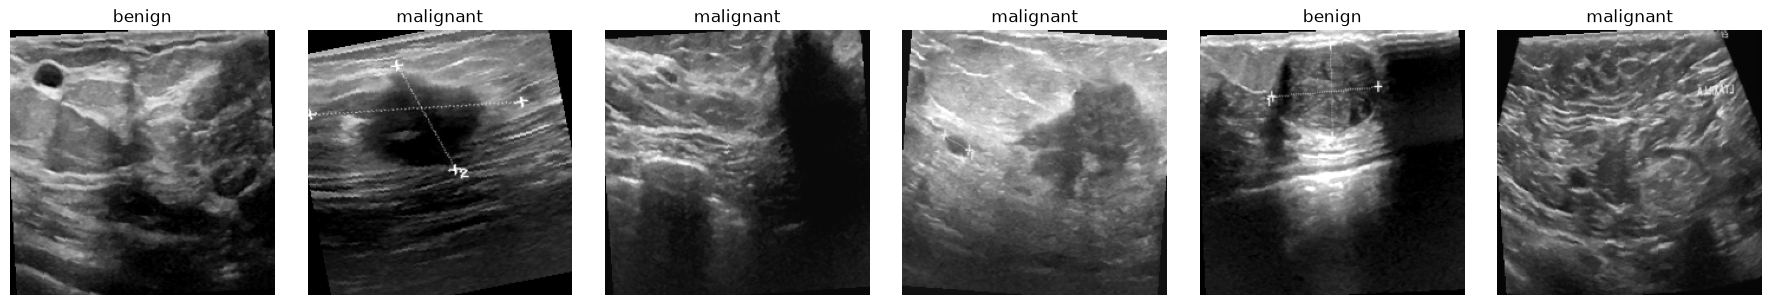

In [8]:
def denormalize(img_tensor):
    """把归一化后的 tensor 还原成可以直接显示的图片（0~1 之间）。"""
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    img = img_tensor * std + mean
    return img.clamp(0, 1).permute(1, 2, 0).numpy()


sample_imgs, sample_labels = next(iter(train_loader))
n_show = min(6, len(sample_imgs))

fig, axes = plt.subplots(1, n_show, figsize=(3 * n_show, 3))
if n_show == 1:
    axes = [axes]
for i in range(n_show):
    axes[i].imshow(denormalize(sample_imgs[i]))
    axes[i].set_title(CLASS_NAMES[sample_labels[i].item()])
    axes[i].axis("off")
plt.tight_layout()
plt.show()


## 6. 构建模型：ResNet50 + ImageNet 预训练权重

- 加载在 ImageNet 上预训练好的 ResNet50，利用它已经学到的通用图像特征（边缘、纹理、形状等），而不是从零开始训练。
- 把原本 1000 类（ImageNet 类别数）的最后一层全连接层，换成输出 2 类（benign / malignant）的全连接层。


In [9]:
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(p=DROPOUT_P),
    nn.Linear(num_features, len(CLASS_NAMES)),
)

# ===== 冻结 backbone：减少可训练参数，降低过拟合风险 =====
# FREEZE_BACKBONE_UNTIL 定义"从哪一层开始解冻"，更靠前的层保持 ImageNet 预训练权重不动
# （requires_grad=False 之后反向传播不会给它们算梯度，优化器也不会更新它们）。
FREEZE_LAYER_ORDER = ["conv1", "bn1", "layer1", "layer2", "layer3", "layer4", "fc"]


def _should_freeze(layer_name, freeze_until):
    if freeze_until is None:
        return False  # 不冻结任何层，等价于第 3 次的全网络微调
    return FREEZE_LAYER_ORDER.index(layer_name) < FREEZE_LAYER_ORDER.index(freeze_until)


for layer_name in FREEZE_LAYER_ORDER:
    if layer_name == "fc":
        continue  # 分类头永远训练，不冻结
    layer = getattr(model, layer_name)
    freeze = _should_freeze(layer_name, FREEZE_BACKBONE_UNTIL)
    for param in layer.parameters():
        param.requires_grad = not freeze

model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"FREEZE_BACKBONE_UNTIL = {FREEZE_BACKBONE_UNTIL!r}")
print(f"可训练参数: {trainable_params:,} / 总参数: {total_params:,} "
      f"({trainable_params / total_params:.1%})")
print(model.fc)


FREEZE_BACKBONE_UNTIL = 'layer3'
可训练参数: 22,067,202 / 总参数: 23,512,130 (93.9%)
Sequential(
  (0): Dropout(p=0.3, inplace=False)
  (1): Linear(in_features=2048, out_features=2, bias=True)
)


## 7. 定义损失函数与优化器

- **损失函数**：交叉熵损失（CrossEntropyLoss），标准的多分类/二分类损失函数。
- **优化器**：Adam，学习率用 CONFIG 里设置的 `LEARNING_RATE`。


In [10]:
# ===== run14：按 malignant/benign 实际数量反比给 CrossEntropyLoss 加 class weight，
# 不硬编码哪个类多/少，从 train_sub_df 实际数据里现算 =====
class_counts = train_sub_df[LABEL_COL].value_counts().sort_index()
class_weights = torch.tensor(
    [len(train_sub_df) / (len(CLASS_NAMES) * class_counts.loc[i]) for i in range(len(CLASS_NAMES))],
    dtype=torch.float32,
).to(device)
print("class_weights (按数量反比，索引对应 CLASS_NAMES):", dict(zip(CLASS_NAMES, class_weights.tolist())))

criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=LABEL_SMOOTHING)
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),  # 只把没被冻结的参数交给优化器
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

if SCHEDULER_TYPE == "cosine":
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)
elif SCHEDULER_TYPE == "plateau":
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=SCHEDULER_FACTOR, patience=SCHEDULER_PATIENCE
    )
elif SCHEDULER_TYPE is None:
    scheduler = None
else:
    raise ValueError(f"未知的 SCHEDULER_TYPE: {SCHEDULER_TYPE!r}")

print(f"criterion: CrossEntropyLoss(label_smoothing={LABEL_SMOOTHING})")
print(f"optimizer: AdamW(lr={LEARNING_RATE}, weight_decay={WEIGHT_DECAY})")
print(f"scheduler: {SCHEDULER_TYPE}")


class_weights (按数量反比，索引对应 CLASS_NAMES): {'malignant': 1.0036495923995972, 'benign': 0.9963768124580383}
criterion: CrossEntropyLoss(label_smoothing=0.1)
optimizer: AdamW(lr=0.0001, weight_decay=0.01)
scheduler: cosine


## 8. 训练循环

每个 epoch 做两件事：
1. **训练阶段**：在训练集上做前向传播（forward）+ 反向传播（backward）+ 更新参数，记录平均 train loss。
2. **评估阶段**：在测试集上只做前向传播（不更新参数），记录平均 test loss，同时顺便算一下当前的测试集准确率。

用 `history` 字典把每个 epoch 的 train loss / test loss 都存下来，方便之后画 loss 曲线。


In [11]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()  # 切换到训练模式（启用 dropout/batchnorm 的训练行为）
    running_loss = 0.0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()          # 清空上一步残留的梯度
        outputs = model(images)        # 前向传播
        loss = criterion(outputs, labels)
        loss.backward()                # 反向传播，计算梯度
        optimizer.step()               # 根据梯度更新参数

        running_loss += loss.item() * images.size(0)
    return running_loss / len(loader.dataset)


@torch.no_grad()  # 评估阶段不需要计算梯度，节省显存/计算
def evaluate(model, loader, criterion, device):
    model.eval()  # 切换到评估模式
    running_loss = 0.0
    all_preds, all_labels = [], []
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        running_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)
        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())

    avg_loss = running_loss / len(loader.dataset)
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    acc = accuracy_score(all_labels, all_preds)
    return avg_loss, acc, all_preds, all_labels



@torch.no_grad()
def get_logits_and_labels(model, loader, device):
    """跑一遍 loader，把模型输出的原始 logits（softmax/CrossEntropy 之前那个，不是 preds）
    和标签都收集起来拼成完整 tensor 返回。给 temperature scaling 用。"""
    model.eval()
    all_logits, all_labels = [], []
    for images, labels in loader:
        images = images.to(device)
        logits = model(images)
        all_logits.append(logits.cpu())
        all_labels.append(labels)
    return torch.cat(all_logits), torch.cat(all_labels)


In [12]:
history = {
    "train_loss": [], "val_loss": [], "val_acc": [], "val_f1": [], "lr": [],
}


def _metric_value(metric_name, val_loss, val_f1):
    return val_loss if metric_name == "val_loss" else val_f1


def _is_better(candidate, best, metric_name):
    # val_loss 越小越好，val_f1 越大越好——方向刚好相反，这里用 metric_name 分开判断，避免写反。
    if metric_name == "val_loss":
        return candidate < best
    return candidate > best


best_metric_value = float("inf") if CHECKPOINT_METRIC == "val_loss" else -1.0
best_f1 = -1.0  # 不管用哪个指标选 checkpoint，都顺便记一下对应那一轮的 val_f1，方便看
best_epoch = None  # 记一下选中的是第几轮，方便跟之前"良性 F1 选出第 5 轮"对比
best_state = None
epochs_no_improve = 0

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, val_preds, val_labels = evaluate(model, val_loader, criterion, device)
    # 从 run14 起，选 checkpoint 用的指标换成 F-beta(beta=2)（recall 权重是 precision 的4倍），
    # 比 run11 用的普通 F1（precision/recall 等权）更偏向"别漏诊恶性"。
    # 变量名仍叫 val_f1（跟之前保持一致，CHECKPOINT_METRIC 等地方不用改），但实际存的是 F-beta(2)。
    val_f1 = fbeta_score(val_labels, val_preds, beta=2, pos_label=MALIGNANT_ID)
    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)
    history["lr"].append(current_lr)

    print(f"Epoch {epoch:02d}/{NUM_EPOCHS} | lr={current_lr:.2e} | train_loss={train_loss:.4f} | "
          f"val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | val_f1={val_f1:.4f}")

    # scheduler 每个 epoch 走一步；plateau 需要看 val_loss，cosine 不需要参数
    if scheduler is not None:
        if SCHEDULER_TYPE == "plateau":
            scheduler.step(val_loss)
        else:
            scheduler.step()

    # ===== early stopping / 保存最佳权重：按 CHECKPOINT_METRIC 指定的指标判断"有没有变好" =====
    # （第 3 次直接拿 test_f1 做这个判断，等于训练阶段已经在用测试集调参，
    # 汇报出来的 test 指标会偏乐观——这一轮改动就是为了修这个问题；
    # CHECKPOINT_METRIC 只是让"看哪个指标"变得可切换，val_f1/val_loss 都只碰 val 集，不碰 test）
    current_metric_value = _metric_value(CHECKPOINT_METRIC, val_loss, val_f1)
    if _is_better(current_metric_value, best_metric_value, CHECKPOINT_METRIC):
        best_metric_value = current_metric_value
        best_f1 = val_f1
        best_epoch = epoch
        best_state = {k: v.clone().cpu() for k, v in model.state_dict().items()}
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= EARLY_STOPPING_PATIENCE:
            print(f"{CHECKPOINT_METRIC} 连续 {EARLY_STOPPING_PATIENCE} 个 epoch 没有变好，"
                  f"提前停止训练（第 {epoch} 轮）。")
            break

model.load_state_dict(best_state)
if CHECKPOINT_METRIC == "val_loss":
    print(f"已加载 val_loss 最低的权重（val_loss={best_metric_value:.4f}，对应 val_f1(恶性)={best_f1:.4f}），"
          f"选中第 {best_epoch} 轮")
else:
    print(f"已加载 val_f1(恶性口径) 最高的权重（val_f1={best_metric_value:.4f}），选中第 {best_epoch} 轮")

history["best_epoch"] = best_epoch
history["checkpoint_metric_pos_label"] = "malignant"
history["checkpoint_metric_type"] = "fbeta2"  # run14起：F-beta(beta=2)，不是普通 F1


Epoch 01/20 | lr=1.00e-04 | train_loss=0.6732 | val_loss=0.6512 | val_acc=0.7115 | val_f1=0.1761


Epoch 02/20 | lr=9.94e-05 | train_loss=0.5426 | val_loss=0.4219 | val_acc=0.8846 | val_f1=0.7188


Epoch 03/20 | lr=9.76e-05 | train_loss=0.4226 | val_loss=0.3682 | val_acc=0.9038 | val_f1=0.7927


Epoch 04/20 | lr=9.46e-05 | train_loss=0.3604 | val_loss=0.4422 | val_acc=0.8462 | val_f1=0.8611


Epoch 05/20 | lr=9.05e-05 | train_loss=0.3012 | val_loss=0.3888 | val_acc=0.9038 | val_f1=0.8529


...

Epoch 12/20 | lr=4.22e-05 | train_loss=0.2322 | val_loss=0.3786 | val_acc=0.8942 | val_f1=0.8284


Epoch 13/20 | lr=3.45e-05 | train_loss=0.2387 | val_loss=0.3831 | val_acc=0.8846 | val_f1=0.7831


Epoch 14/20 | lr=2.73e-05 | train_loss=0.2602 | val_loss=0.3724 | val_acc=0.9038 | val_f1=0.8721


Epoch 15/20 | lr=2.06e-05 | train_loss=0.2387 | val_loss=0.3914 | val_acc=0.8942 | val_f1=0.7879


Epoch 16/20 | lr=1.46e-05 | train_loss=0.2360 | val_loss=0.3783 | val_acc=0.9038 | val_f1=0.8333
val_f1 连续 8 个 epoch 没有变好，提前停止训练（第 16 轮）。
已加载 val_f1(恶性口径) 最高的权重（val_f1=0.9143），选中第 8 轮


### 8.5 可选：K 折交叉验证（诊断稳定性，默认关闭）
只是想看看换一种数据切分方式，val F1 稳不稳定；不影响上面正式训练出的 `model`/`history`，也完全不碰 test 集。`USE_KFOLD=True` 才会跑，默认跳过。


In [13]:
import json

if USE_KFOLD:
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)
    fold_f1_scores = []
    fold_acc_scores = []

    # 只在原始 train.xlsx（train_df）内部切，跟上面单次 train_sub/val 划分互不影响，
    # test 集依然完全不参与——这里只是诊断"划分方式换一下，结果稳不稳"。
    for fold_idx, (fold_train_idx, fold_val_idx) in enumerate(
        skf.split(train_df, train_df[LABEL_COL]), start=1
    ):
        fold_train_df = train_df.iloc[fold_train_idx].reset_index(drop=True)
        fold_val_df = train_df.iloc[fold_val_idx].reset_index(drop=True)

        fold_train_dataset = BUSIDataset(fold_train_df, IMAGES_ROOT, IMAGE_COL, LABEL_COL, LABEL_MAP, transform=train_transform)
        fold_val_dataset = BUSIDataset(fold_val_df, IMAGES_ROOT, IMAGE_COL, LABEL_COL, LABEL_MAP, transform=eval_transform)
        fold_train_loader = DataLoader(fold_train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
        fold_val_loader = DataLoader(fold_val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

        # 每一折都从 ImageNet 预训练权重重新开始，用跟主流程一样的冻结策略/超参数
        fold_model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        fold_model.fc = nn.Sequential(nn.Dropout(p=DROPOUT_P), nn.Linear(fold_model.fc.in_features, len(CLASS_NAMES)))
        for layer_name in FREEZE_LAYER_ORDER:
            if layer_name == "fc":
                continue
            for param in getattr(fold_model, layer_name).parameters():
                param.requires_grad = not _should_freeze(layer_name, FREEZE_BACKBONE_UNTIL)
        fold_model = fold_model.to(device)

        # run18：跟 run14 一样，按这一折 train 数据的实际数量反比算 class weight，不硬编码
        fold_class_counts = fold_train_df[LABEL_COL].value_counts().sort_index()
        fold_class_weights = torch.tensor(
            [len(fold_train_df) / (len(CLASS_NAMES) * fold_class_counts.loc[i]) for i in range(len(CLASS_NAMES))],
            dtype=torch.float32,
        ).to(device)
        fold_criterion = nn.CrossEntropyLoss(weight=fold_class_weights, label_smoothing=LABEL_SMOOTHING)
        fold_optimizer = torch.optim.AdamW(
            filter(lambda p: p.requires_grad, fold_model.parameters()),
            lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY,
        )

        # run18：选"这一折最好的一轮"改用 F-beta(2)（malignant 口径，跟 run14 一样），
        # 每次刷新最优时把权重也存下来，这一折跑完后存成 {RUN_TAG}_fold{fold_idx}_model.pt，给 ensemble 用
        fold_best_f1 = -1.0
        fold_best_acc = None
        fold_best_state = None
        for fold_epoch in range(1, NUM_EPOCHS + 1):
            train_one_epoch(fold_model, fold_train_loader, fold_criterion, fold_optimizer, device)
            _, fold_val_acc, fold_preds, fold_labels = evaluate(fold_model, fold_val_loader, fold_criterion, device)
            fold_val_f1 = fbeta_score(fold_labels, fold_preds, beta=2, pos_label=MALIGNANT_ID)
            if fold_val_f1 > fold_best_f1:
                fold_best_f1 = fold_val_f1
                fold_best_acc = fold_val_acc
                fold_best_state = {k: v.clone().cpu() for k, v in fold_model.state_dict().items()}

        fold_model_path = os.path.join(OUTPUT_DIR, f"{RUN_TAG}_fold{fold_idx}_model.pt")
        torch.save(fold_best_state, fold_model_path)

        fold_f1_scores.append(fold_best_f1)
        fold_acc_scores.append(fold_best_acc)
        print(f"Fold {fold_idx}/{N_FOLDS} | 训练 {len(fold_train_df)} / 验证 {len(fold_val_df)} | "
              f"best val acc = {fold_best_acc:.4f} | best val F-beta(2) = {fold_best_f1:.4f} | "
              f"权重已存到 {fold_model_path}")

    fold_f1_scores = np.array(fold_f1_scores)
    fold_acc_scores = np.array(fold_acc_scores)
    print(f"\nK-Fold ({N_FOLDS} 折) val accuracy: {fold_acc_scores.round(4).tolist()}")
    print(f"均值: {fold_acc_scores.mean():.4f} +/- {fold_acc_scores.std():.4f}")
    print(f"K-Fold ({N_FOLDS} 折) val F-beta(2) [malignant]: {fold_f1_scores.round(4).tolist()}")
    print(f"均值: {fold_f1_scores.mean():.4f} +/- {fold_f1_scores.std():.4f}")

    kfold_results = {
        "n_folds": N_FOLDS,
        "checkpoint_metric_type": "fbeta2_malignant",  # run18 起：不再是普通 F1
        "fold_val_acc": fold_acc_scores.tolist(),
        "fold_val_f1": fold_f1_scores.tolist(),
        "val_acc_mean": float(fold_acc_scores.mean()),
        "val_acc_std": float(fold_acc_scores.std()),
        "val_f1_mean": float(fold_f1_scores.mean()),
        "val_f1_std": float(fold_f1_scores.std()),
    }
    kfold_save_path = os.path.join(OUTPUT_DIR, f"{RUN_TAG}_kfold_results.json")
    with open(kfold_save_path, "w") as f:
        json.dump(kfold_results, f, indent=2)
    print("K-Fold 结果已保存到:", kfold_save_path)
else:
    print("USE_KFOLD=False，跳过 K 折交叉验证（改成 True 后重新跑这一格即可）。")


USE_KFOLD=False，跳过 K 折交叉验证（改成 True 后重新跑这一格即可）。


## 9. 绘制 Loss 曲线

观察 train loss 和 test loss 随 epoch 的变化：
- 如果两条曲线都在下降，说明模型还在学习（可能欠拟合 underfitting，还没训够）。
- 如果 train loss 持续下降但 test loss 开始回升，说明模型开始**过拟合（overfitting）**——在训练集上学得很好，但泛化能力变差。
- 好的训练轮数（epoch 数），一般选在 test loss 最低、还没有明显回升的地方。


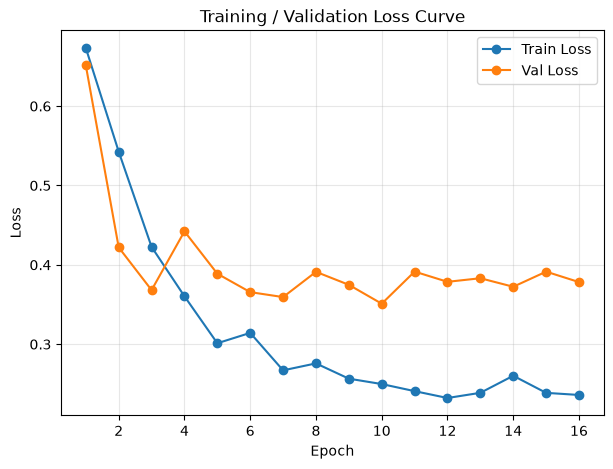

Train/Val loss 曲线已保存到: /mnt/cv_data/users/hahaxixi/projects/research_training/outputs/run19_loss_curve.png


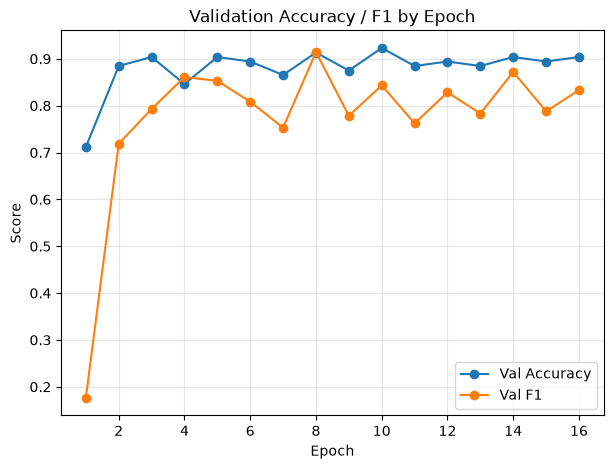

Val accuracy/F1 曲线已保存到: /mnt/cv_data/users/hahaxixi/projects/research_training/outputs/run19_metrics_curve.png


In [14]:
epochs_range = range(1, len(history["train_loss"]) + 1)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(epochs_range, history["train_loss"], label="Train Loss", marker="o")
ax.plot(epochs_range, history["val_loss"], label="Val Loss", marker="o")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training / Validation Loss Curve")
ax.legend()
ax.grid(alpha=0.3)
fig.savefig(LOSS_CURVE_VAL_PATH, dpi=150, bbox_inches="tight")
plt.show()
print("Train/Val loss 曲线已保存到:", LOSS_CURVE_VAL_PATH)

fig2, ax2 = plt.subplots(figsize=(7, 5))
ax2.plot(epochs_range, history["val_acc"], label="Val Accuracy", marker="o")
ax2.plot(epochs_range, history["val_f1"], label="Val F1", marker="o")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Score")
ax2.set_title("Validation Accuracy / F1 by Epoch")
ax2.legend()
ax2.grid(alpha=0.3)
fig2.savefig(VAL_METRICS_CURVE_PATH, dpi=150, bbox_inches="tight")
plt.show()
print("Val accuracy/F1 曲线已保存到:", VAL_METRICS_CURVE_PATH)


### 9.1 过拟合分析（草稿，待自己改写精简）

从 loss 曲线看：train loss 从 epoch 1 的 0.6174 一路降到 epoch 20 的 0.0069，几乎完美拟合了训练集；
但 test loss 只在 epoch 4 附近降到最低点（0.2901），之后不再下降，反而在 0.29~0.53 之间反复震荡，
epoch 15 甚至回升到 0.5318。这说明 epoch 4 之后模型已经进入**过拟合**：模型在"死记"训练集里的
细节，而不是学习能泛化到新图片的特征。可能原因是训练集只有 517 张图，对 ResNet50 这种大容量模型
偏小，加上数据增强只有水平翻转、又没有 dropout/weight decay 等正则化手段，导致模型很容易记住训练
样本。常见对策：early stopping（在 test loss 最低的 epoch 4 附近停止/保存 checkpoint）、加强数据
增强（随机裁剪、旋转、颜色扰动）、在全连接层前加 dropout、给优化器加 weight decay。


### 9.2 保存每个 epoch 的原始数据（方便以后对比）


In [15]:
# 把每个 epoch 的原始数字存下来（不是只存图），这样以后再改代码、再对比新旧结果时，
# 不会因为重新跑 notebook 覆盖了 outputs 而找不到旧数据。
import json

with open(HISTORY_VAL_SAVE_PATH, "w") as f:
    json.dump(history, f, indent=2)
print("每个 epoch 的 train/val loss、accuracy、F1、学习率已保存到:", HISTORY_VAL_SAVE_PATH)


每个 epoch 的 train/val loss、accuracy、F1、学习率已保存到: /mnt/cv_data/users/hahaxixi/projects/research_training/outputs/run19_history.json


### 9.3 Temperature Scaling（概率校准，不重新训练模型）

只学一个标量 T，训练后把 logits 除以 T 再算 loss/概率：这不会改变 argmax（预测类别、
accuracy/precision/recall/F1 都不受影响），但能让模型输出的置信度更接近真实概率，
用来诊断/缓解"accuracy 还行但 loss 压不下去"（模型对预测过度自信）的情况。
T 只用 val 集拟合，跟 test 集完全无关；test 集这里只是顺便算一下校准前后 loss 差多少，
不影响后面第 10 节的 accuracy/precision/recall/F1 计算。


In [16]:
# ===== 在 val 集上拟合 temperature =====
val_logits, val_labels_t = get_logits_and_labels(model, val_loader, device)

temperature = torch.nn.Parameter(torch.ones(1) * 1.0)
temp_optimizer = torch.optim.LBFGS([temperature], lr=0.01, max_iter=50)
temp_criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

val_loss_before = temp_criterion(val_logits, val_labels_t).item()


def _temp_closure():
    temp_optimizer.zero_grad()
    loss = temp_criterion(val_logits / temperature, val_labels_t)
    loss.backward()
    return loss


temp_optimizer.step(_temp_closure)

with torch.no_grad():
    val_loss_after = temp_criterion(val_logits / temperature, val_labels_t).item()

learned_temperature = temperature.item()
print(f"Temperature scaling（在 val 集上拟合）：")
print(f"  T=1.0（未校准）  val loss = {val_loss_before:.4f}")
print(f"  T={learned_temperature:.4f}（校准后）val loss = {val_loss_after:.4f}")

# ===== 顺便看看校准前后 test loss 差多少（accuracy/precision/recall/F1 不受 T 影响，不用重新算）=====
test_logits, test_labels_t = get_logits_and_labels(model, test_loader, device)
with torch.no_grad():
    test_loss_uncalibrated = temp_criterion(test_logits, test_labels_t).item()
    test_loss_calibrated = temp_criterion(test_logits / temperature, test_labels_t).item()

print(f"\nTest loss：")
print(f"  T=1.0（未校准）  test loss = {test_loss_uncalibrated:.4f}")
print(f"  T={learned_temperature:.4f}（校准后）test loss = {test_loss_calibrated:.4f}")
print("（这两个只是校准前后的 loss 对比，第 10 节的 accuracy/precision/recall/F1 只看 argmax，跟 T 无关）")

# ===== 把 temperature 和校准前后的 test loss 补存进这次跑的 history json（不覆盖已有字段）=====
history["temperature"] = learned_temperature
history["test_loss_uncalibrated"] = test_loss_uncalibrated
history["test_loss_calibrated"] = test_loss_calibrated
with open(HISTORY_VAL_SAVE_PATH, "w") as f:
    json.dump(history, f, indent=2)
print("\ntemperature 和校准前后的 test loss 已经补存到:", HISTORY_VAL_SAVE_PATH)


Temperature scaling（在 val 集上拟合）：
  T=1.0（未校准）  val loss = 0.3910
  T=1.0482（校准后）val loss = 0.3892



Test loss：
  T=1.0（未校准）  test loss = 0.4522
  T=1.0482（校准后）test loss = 0.4480
（这两个只是校准前后的 loss 对比，第 10 节的 accuracy/precision/recall/F1 只看 argmax，跟 T 无关）

temperature 和校准前后的 test loss 已经补存到: /mnt/cv_data/users/hahaxixi/projects/research_training/outputs/run19_history.json


## 10. 在测试集上计算分类指标

用标准的分类评估指标：
- **Accuracy（准确率）**：预测对的比例。
- **Precision / Recall / F1**：sklearn 默认按 `pos_label=1` 算——核实过数字标签含义后（见 3.1 节），
  `1` 对应的其实是 **benign（良性）**，不是恶性。也就是说，下面先打印出来的 Precision/Recall/F1
  是"良性"口径的，用来跟 run1~run10 的历史数字直接对比；**真正在医学筛查场景里更该关心的"恶性
  （malignant）有没有被漏诊"，要看后面按类别拆分（`classification_report`）打印出来的 malignant 那一行**
  （不想漏掉恶性病例，主要看 malignant 的 recall）。
- **混淆矩阵（confusion matrix）**：更直观地看到哪类样本容易被搞混。


Test Accuracy : 0.8615
Precision     : 0.9398
Recall        : 0.8571
F1 score      : 0.8966
Test Loss（未校准, T=1.0）     : 0.4522
Test Loss（校准后, T=1.0482）: 0.4480
Confusion matrix (行=真实标签, 列=预测标签):
[[34  5]
 [13 78]]

按类别拆分（malignant vs benign）precision/recall/f1：
              precision    recall  f1-score   support

   malignant       0.72      0.87      0.79        39
      benign       0.94      0.86      0.90        91

    accuracy                           0.86       130
   macro avg       0.83      0.86      0.84       130
weighted avg       0.87      0.86      0.86       130

malignant F-beta(2)（选 checkpoint 用的指标）: 0.8374

三次结果对比：
                              accuracy precision    recall        f1
第 1 次 (baseline)                0.9077    0.9247    0.9451    0.9348
第 3 次 (test 集调参)                0.9385    0.9462    0.9670    0.9565
当前 (val 调参，test 全程未碰)           0.8615    0.9398    0.8571    0.8966
按类别拆分的指标、checkpoint 选中轮次已经补存到: /mnt/cv_data/users/hahaxixi/projects/research_tr

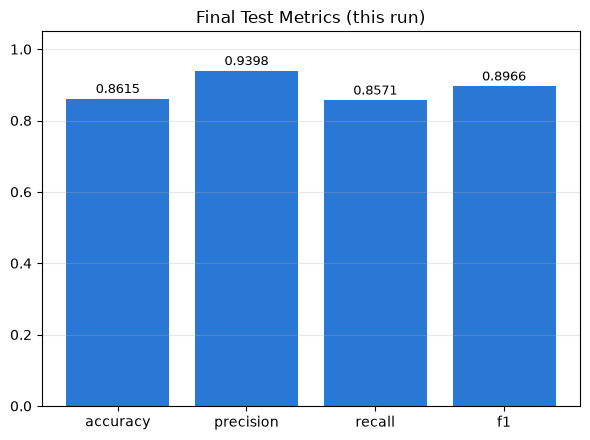

最终 test 指标柱状图已保存到: /mnt/cv_data/users/hahaxixi/projects/research_training/outputs/run19_test_metrics.png


In [17]:
# ===== 训练/调参阶段完全没碰过 test.xlsx 的 130 条；上面 9.3 节为了算 temperature 校准前后的 loss
# 顺便跑过一次 test 集的 logits，但那只是诊断 loss 用，不影响这里的预测/accuracy/precision/recall/F1 =====
final_test_loss, final_test_acc, final_preds, final_labels = evaluate(model, test_loader, criterion, device)

# 沿用之前的默认口径（sklearn pos_label=1，也就是 benign），只是为了跟 run1~run10 的历史数字直接对比，
# 不代表这是我们真正关心的口径——医学筛查场景应该看 malignant，见下面的按类别拆分。
precision = precision_score(final_labels, final_preds)
recall = recall_score(final_labels, final_preds)
f1 = f1_score(final_labels, final_preds)
cm = confusion_matrix(final_labels, final_preds)

from sklearn.metrics import classification_report

# 按类别拆开算 precision/recall/f1（docs/IDEAL_RESULT.md 第 2 条要求的恶性口径，就在这里面）
class_report_str = classification_report(final_labels, final_preds, target_names=CLASS_NAMES)
class_report_dict = classification_report(final_labels, final_preds, target_names=CLASS_NAMES, output_dict=True)
precision_malignant = class_report_dict["malignant"]["precision"]
recall_malignant = class_report_dict["malignant"]["recall"]
f1_malignant = class_report_dict["malignant"]["f1-score"]
precision_benign = class_report_dict["benign"]["precision"]
recall_benign = class_report_dict["benign"]["recall"]
f1_benign = class_report_dict["benign"]["f1-score"]

# run14：选 checkpoint 用的是 F-beta(2)，顺便在 test 集上也算一下看实际效果
f2_malignant = fbeta_score(final_labels, final_preds, beta=2, pos_label=MALIGNANT_ID)

print(f"Test Accuracy : {final_test_acc:.4f}")
print(f"Precision     : {precision:.4f}")
print(f"Recall        : {recall:.4f}")
print(f"F1 score      : {f1:.4f}")
# 汇报用的 test loss 用 9.3 节 temperature 校准后的那个（更准，不是 T=1 时偏乐观/悲观的原始值）
print(f"Test Loss（未校准, T=1.0）     : {test_loss_uncalibrated:.4f}")
print(f"Test Loss（校准后, T={learned_temperature:.4f}）: {test_loss_calibrated:.4f}")
print("Confusion matrix (行=真实标签, 列=预测标签):")
print(cm)
print()
print("按类别拆分（malignant vs benign）precision/recall/f1：")
print(class_report_str)
print(f"malignant F-beta(2)（选 checkpoint 用的指标）: {f2_malignant:.4f}")

# ===== 和之前两次结果对比 =====
# 第 1 次：无正则化，明显过拟合
# 第 3 次：数据增强 + AdamW weight decay + dropout + early stopping（但当时拿 test 集做 early stopping，"偷看"了测试集）
# 这一次：train/val/test 三路切分（early stopping 只看 val）+ 冻结 backbone + label smoothing + LR scheduler
runs = {
    "第 1 次 (baseline)": {"accuracy": 0.9077, "precision": 0.9247, "recall": 0.9451, "f1": 0.9348},
    "第 3 次 (test 集调参)": {"accuracy": 0.9385, "precision": 0.9462, "recall": 0.9670, "f1": 0.9565},
    "当前 (val 调参，test 全程未碰)": {"accuracy": final_test_acc, "precision": precision, "recall": recall, "f1": f1},
}
print("\n三次结果对比：")
metric_names = ["accuracy", "precision", "recall", "f1"]
header = f"{'':28s}" + "".join(f"{m:>10s}" for m in metric_names)
print(header)
for run_name, vals in runs.items():
    print(f"{run_name:28s}" + "".join(f"{vals[m]:>10.4f}" for m in metric_names))

# ===== 把按类别拆分的结果、checkpoint 选中的轮次，一起补存进这次的 history json =====
history["malignant_id"] = int(MALIGNANT_ID)
history["classification_report"] = class_report_dict
history["test_accuracy"] = float(final_test_acc)
history["malignant_f2"] = float(f2_malignant)
with open(HISTORY_VAL_SAVE_PATH, "w") as f:
    json.dump(history, f, indent=2)
print("按类别拆分的指标、checkpoint 选中轮次已经补存到:", HISTORY_VAL_SAVE_PATH)

# ===== 最终 test 集指标柱状图：只在训练全部结束、只跑一次 test 集之后生成，不跟逐 epoch 曲线混在一起 =====
fig, ax = plt.subplots(figsize=(6, 4.5))
bars = ax.bar(metric_names, [final_test_acc, precision, recall, f1], color="#2a78d6")
for b in bars:
    h = b.get_height()
    ax.annotate(f"{h:.4f}", xy=(b.get_x() + b.get_width() / 2, h), xytext=(0, 4),
                textcoords="offset points", ha="center", fontsize=9)
ax.set_ylim(0, 1.05)
# 标题用英文：服务器 matplotlib 默认字体不支持中文，中文会显示成方框乱码（同 11 节的做法）
ax.set_title("Final Test Metrics (this run)")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(TEST_METRICS_BAR_PATH, dpi=150, bbox_inches="tight")
plt.show()
print("最终 test 指标柱状图已保存到:", TEST_METRICS_BAR_PATH)


### 10.5 新旧 checkpoint 对比：良性 F1 选出的旧权重 vs 恶性 F1 选出的新权重（run11）

上面第 9.4 节评估的是这次（run11）按恶性(malignant) F1 选出来的新 checkpoint。这里额外加载 run8/9/10 用的旧 checkpoint（当时按良性 F1 选），在同一个 test 集上跑一次评估，直接对比"改了选择标准之后，各类别的 precision/recall/f1 有没有变化、选中的还是不是第 5 轮"。

In [18]:
import json as _json  # 保险起见单独 import 一次，不依赖前面 cell 是否跑过

# 旧 checkpoint 选中的是第几轮：从 run8_history.json 的 val_f1（良性口径）数组里找最大值位置，
# 不硬编码假设是第 5 轮
with open(os.path.join(OUTPUT_DIR, "run8_history.json")) as f:
    _old_history = _json.load(f)
old_best_epoch = int(np.argmax(_old_history["val_f1"])) + 1

# 重建同样架构的模型，加载旧 checkpoint 权重（run8/9/10 三次训练选出来的是同一份权重）
old_model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
old_model.fc = nn.Sequential(nn.Dropout(p=DROPOUT_P), nn.Linear(old_model.fc.in_features, len(CLASS_NAMES)))
old_model.load_state_dict(torch.load(os.path.join(OUTPUT_DIR, "run10_model.pt"), map_location=device))
old_model = old_model.to(device)

_, old_test_acc, old_preds, old_labels = evaluate(old_model, test_loader, criterion, device)
old_report = classification_report(old_labels, old_preds, target_names=CLASS_NAMES, output_dict=True)

print(f"旧 checkpoint（run8/9/10，按良性 F1 选，第 {old_best_epoch} 轮）test accuracy: {old_test_acc:.4f}")
print(f"新 checkpoint（{RUN_TAG}，按 CHECKPOINT_METRIC={CHECKPOINT_METRIC!r} 选，第 {best_epoch} 轮）test accuracy: {final_test_acc:.4f}")
print()

rows = [
    ("benign", "precision"), ("benign", "recall"), ("benign", "f1-score"),
    ("malignant", "precision"), ("malignant", "recall"), ("malignant", "f1-score"),
]
print(f"{'':22s}{'old(良性F1选,第' + str(old_best_epoch) + '轮)':>24s}{'new(第' + str(best_epoch) + '轮)':>24s}")
for cls, metric in rows:
    old_v = old_report[cls][metric]
    new_v = class_report_dict[cls][metric]
    print(f"{cls + ' ' + metric:22s}{old_v:>24.4f}{new_v:>24.4f}")

# 存进这次的 history，方便以后回顾
history["old_checkpoint_comparison"] = {
    "old_best_epoch": old_best_epoch,
    "old_test_accuracy": float(old_test_acc),
    "old_classification_report": old_report,
    "new_best_epoch": best_epoch,
    "new_test_accuracy": float(final_test_acc),
}
with open(HISTORY_VAL_SAVE_PATH, "w") as f:
    _json.dump(history, f, indent=2)
print("\n新旧 checkpoint 对比结果已经补存到:", HISTORY_VAL_SAVE_PATH)

旧 checkpoint（run8/9/10，按良性 F1 选，第 5 轮）test accuracy: 0.8692
新 checkpoint（run19，按 CHECKPOINT_METRIC='val_f1' 选，第 8 轮）test accuracy: 0.8615

                                old(良性F1选,第5轮)                new(第8轮)
benign precision                        0.9302                  0.9398
benign recall                           0.8791                  0.8571
benign f1-score                         0.9040                  0.8966
malignant precision                     0.7500                  0.7234
malignant recall                        0.8462                  0.8718
malignant f1-score                      0.7952                  0.7907

新旧 checkpoint 对比结果已经补存到: /mnt/cv_data/users/hahaxixi/projects/research_training/outputs/run19_history.json


### 10.6 Ensemble：5 折模型概率平均，能不能救回边界漏诊病例

上面 9.4 节 5 折交叉验证时，每一折都用 run14 同款配置（class weight + F-beta(2) 选 checkpoint）重新训练，并把每折最优权重存了下来（`{RUN_TAG}_fold1_model.pt` ~ `fold5_model.pt`）。这里加载这 5 份权重，分别对 test 集推理拿到恶性概率，取 5 个模型的平均概率作为集成(ensemble)结果，跟单模型（这次 run18 自己的单次结果，配置应该跟 run14 基本一致）对比，并顺便检查一下 run14 之前漏诊的 4 个恶性病例，集成之后有没有被救回来。

In [19]:
if USE_KFOLD:
    # ===== 用 5 折各自的最优权重，对 test 集分别推理，取恶性概率的平均值 =====
    ensemble_probs = np.zeros(len(test_dataset))
    for fold_idx in range(1, N_FOLDS + 1):
        fold_model_path = os.path.join(OUTPUT_DIR, f"{RUN_TAG}_fold{fold_idx}_model.pt")
        eval_model = models.resnet50(weights=None)  # 只加载已训练权重，不需要重新下载 ImageNet 预训练权重
        eval_model.fc = nn.Sequential(nn.Dropout(p=DROPOUT_P), nn.Linear(eval_model.fc.in_features, len(CLASS_NAMES)))
        eval_model.load_state_dict(torch.load(fold_model_path, map_location=device))
        eval_model = eval_model.to(device)
        eval_model.eval()

        fold_probs = []
        with torch.no_grad():
            for images, _ in test_loader:
                images = images.to(device)
                logits = eval_model(images)
                probs = torch.softmax(logits, dim=1)
                fold_probs.append(probs[:, MALIGNANT_ID].cpu().numpy())
        ensemble_probs += np.concatenate(fold_probs)
    ensemble_probs /= N_FOLDS

    # 默认门槛 0.5，跟单模型报告口径一致；final_labels 顺序跟 test_loader（shuffle=False）一致，可以直接复用
    ensemble_preds = np.where(ensemble_probs > 0.5, MALIGNANT_ID, 1 - MALIGNANT_ID)
    precision_ensemble = precision_score(final_labels, ensemble_preds, pos_label=MALIGNANT_ID)
    recall_ensemble = recall_score(final_labels, ensemble_preds, pos_label=MALIGNANT_ID)
    f1_ensemble = f1_score(final_labels, ensemble_preds, pos_label=MALIGNANT_ID)

    print("单模型（这次 run18 自己训练出来的，配置同 run14）malignant precision/recall/f1: "
          f"{precision_malignant:.4f} / {recall_malignant:.4f} / {f1_malignant:.4f}")
    print(f"Ensemble（5 折平均概率，门槛 0.5）malignant precision/recall/f1: "
          f"{precision_ensemble:.4f} / {recall_ensemble:.4f} / {f1_ensemble:.4f}")

    # ===== 检查 run14 之前漏诊的 4 个恶性病例，这次集成之后有没有被救回来 =====
    missed_filenames = ["malignant (145).png", "malignant (52).png", "malignant (28).png", "malignant (148).png"]
    missed_case_check = {}
    for fname in missed_filenames:
        match_idx = test_df.index[test_df[IMAGE_COL] == fname]
        if len(match_idx) == 0:
            continue
        idx = match_idx[0]
        missed_case_check[fname] = {
            "ensemble_prob_malignant": float(ensemble_probs[idx]),
            "ensemble_pred": CLASS_NAMES[int(ensemble_preds[idx])],
            "now_correct": bool(ensemble_preds[idx] == MALIGNANT_ID),
        }
    print("\nrun14 之前漏诊的 4 个恶性病例，集成之后：")
    for fname, info in missed_case_check.items():
        status = "✅ 救回来了" if info["now_correct"] else "❌ 还是漏诊"
        print(f"  {fname}: P(malignant)={info['ensemble_prob_malignant']:.4f} -> {info['ensemble_pred']} | {status}")

    ensemble_results = {
        "n_folds": N_FOLDS,
        "single_model_precision_malignant": float(precision_malignant),
        "single_model_recall_malignant": float(recall_malignant),
        "single_model_f1_malignant": float(f1_malignant),
        "ensemble_precision_malignant": float(precision_ensemble),
        "ensemble_recall_malignant": float(recall_ensemble),
        "ensemble_f1_malignant": float(f1_ensemble),
        "missed_case_check": missed_case_check,
    }
    ensemble_save_path = os.path.join(OUTPUT_DIR, f"{RUN_TAG}_ensemble_results.json")
    with open(ensemble_save_path, "w") as f:
        json.dump(ensemble_results, f, indent=2)
    print("\nEnsemble 结果已保存到:", ensemble_save_path)
else:
    print("USE_KFOLD=False，没有每折权重，跳过 ensemble 评估。")

USE_KFOLD=False，没有每折权重，跳过 ensemble 评估。


## 11. 可视化预测结果

遍历测试集里的每一张图片，显示：**图片本身 + 真实标签 + 预测标签**。
预测错误的图片会用红色标题标出来，方便一眼看出模型容易在哪些图上犯错。

⚠️ 如果测试集很大，这一步会输出很多张图；可以把下面的 `MAX_IMAGES_TO_SHOW` 调小一点先看看效果。


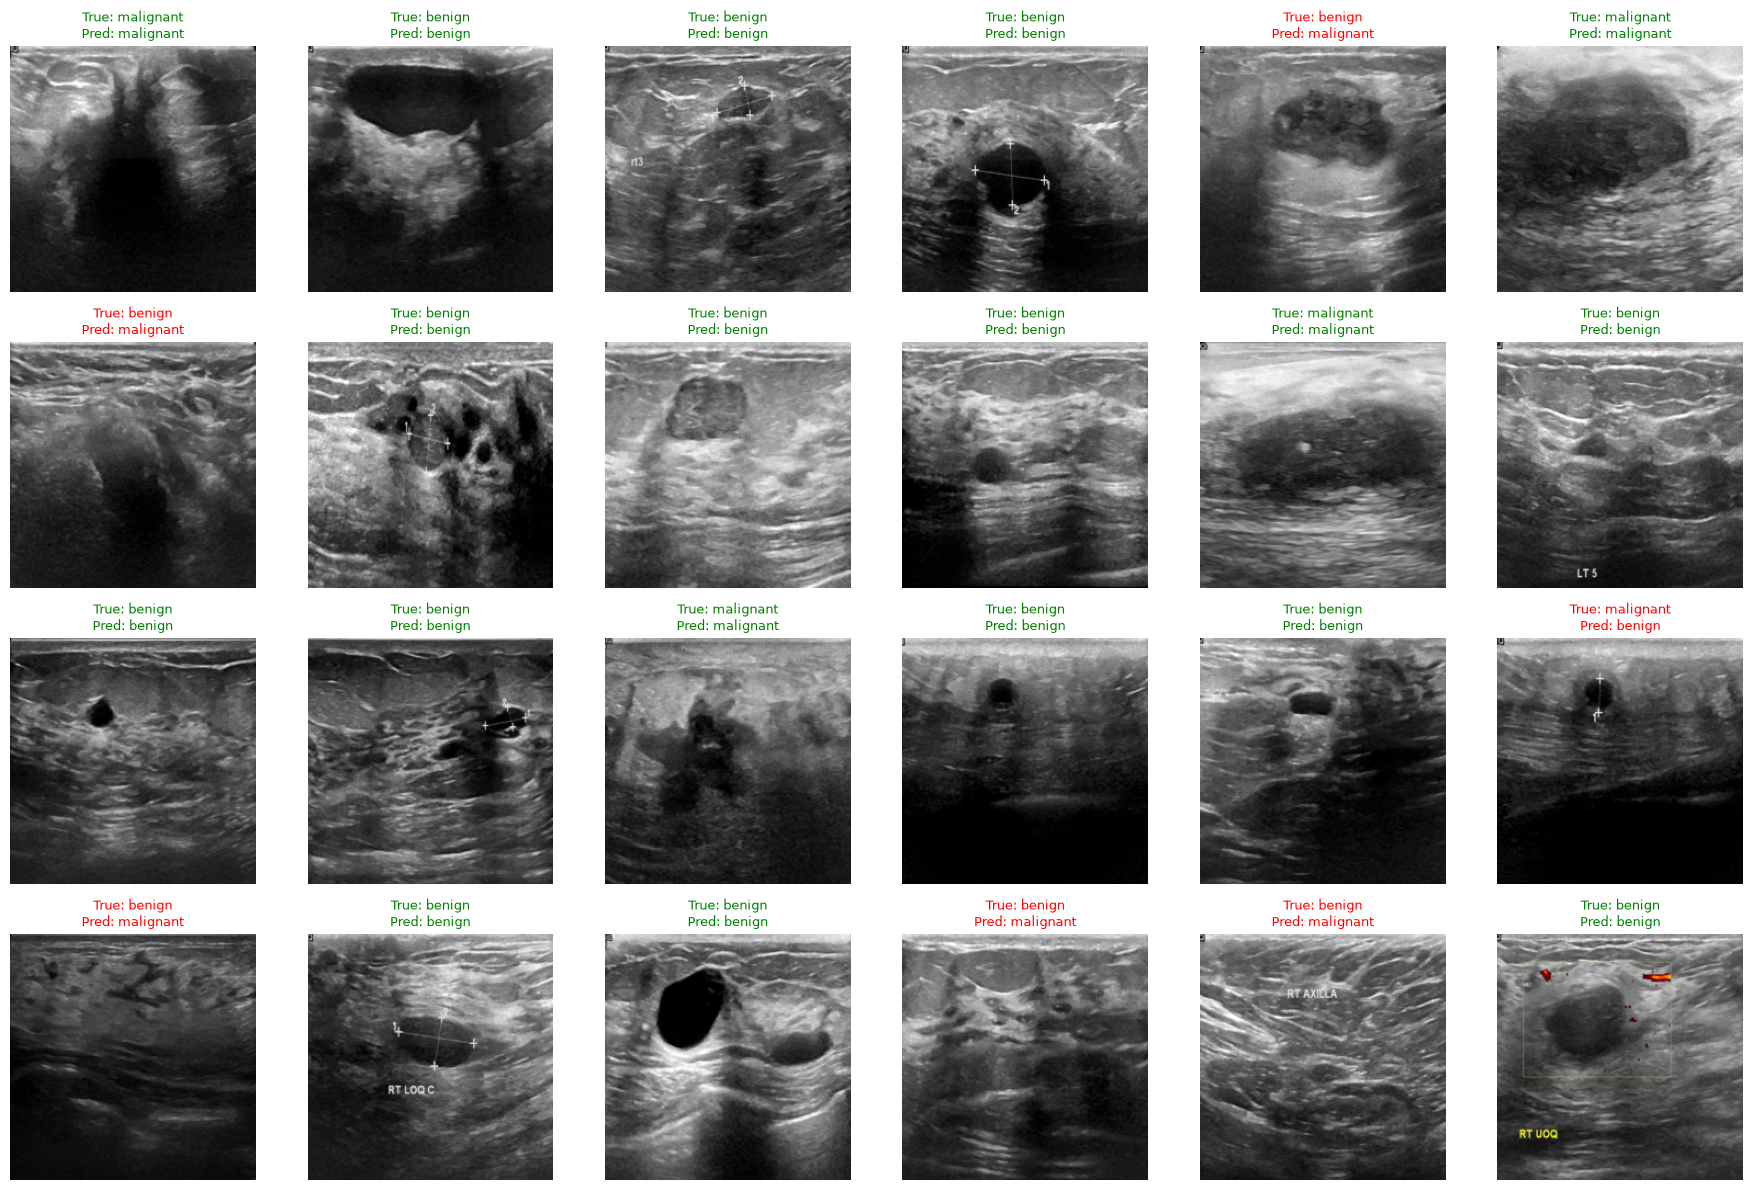

In [20]:
MAX_IMAGES_TO_SHOW = 24  # 想看全部测试图片就设成 len(test_dataset)

model.eval()
n_show = min(MAX_IMAGES_TO_SHOW, len(test_dataset))
n_cols = 6
n_rows = (n_show + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 3 * n_rows))
axes = np.array(axes).reshape(-1)

with torch.no_grad():
    for i in range(n_show):
        image, true_label = test_dataset[i]
        output = model(image.unsqueeze(0).to(device))
        pred_label = output.argmax(dim=1).item()

        ax = axes[i]
        ax.imshow(denormalize(image))
        # 注意：标题用英文 True/Pred，因为服务器上 matplotlib 默认字体不支持中文，
        # 中文会显示成方框乱码
        title = f"True: {CLASS_NAMES[true_label]}\nPred: {CLASS_NAMES[pred_label]}"
        ax.set_title(title, color=("green" if pred_label == true_label else "red"), fontsize=9)
        ax.axis("off")

for j in range(n_show, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()


## 12. 保存模型

把训练好的模型权重保存下来，之后可以直接加载，不用重新训练。


In [21]:
torch.save(model.state_dict(), MODEL_SAVE_PATH)
print("模型已保存到:", MODEL_SAVE_PATH)


模型已保存到: /mnt/cv_data/users/hahaxixi/projects/research_training/outputs/run19_model.pt
